PROYECTO FINAL TAREA 2: REGRESIÓN

PREDECIR EL RENDIMIENTO FUTURO 

In [34]:
#LIBRERÍAS 

import numpy as np
import pandas as pd

#visualización
import matplotlib.pyplot as plt
import seaborn as sns

#preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#modelos de regresión
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#split
from sklearn.model_selection import train_test_split

#validación cruzada
from sklearn.model_selection import cross_val_score


In [35]:
#cargamos los datos
df = pd.read_csv('rendimiento_estudiantes.csv', sep=';')

In [36]:
#vemos las primera filas
df.head()

,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


In [37]:
"""
Eliminamos las variables del segundo semestre para evitar usar 
información futura y garantizar una predicción realista.
"""
#identificamos columnas del segundo semestre
columns_2sem = [col for col in df.columns if '2sem' in col and col!='nota_media_2sem']

#las eliminamos
df = df.drop(columns=columns_2sem)


In [38]:
X = df.drop(columns='nota_media_2sem')
y = df['nota_media_2sem']

In [39]:
#hacemos el split en train, validación y test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.25, random_state=42
)

In [40]:
y_train.describe()

count    2654.000000
mean       10.217103
std         5.209533
min         0.000000
25%        10.800000
50%        12.200000
75%        13.333333
max        18.571429
Name: nota_media_2sem, dtype: float64

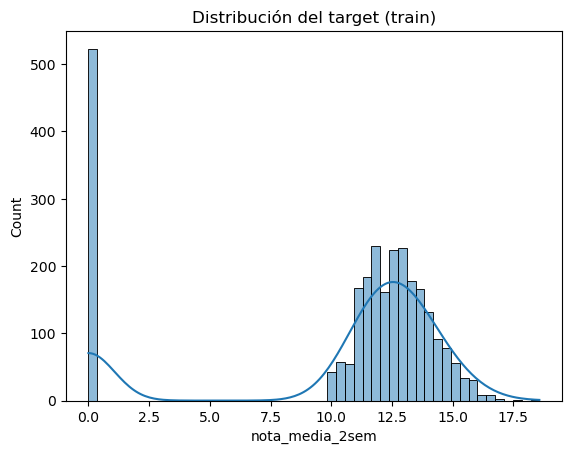

In [41]:
sns.histplot(y_train, kde=True)
plt.title('Distribución del target (train)')
plt.show()


La variable objetivo presenta una media de 10.21 y una mediana de 12.2, lo que indica una distribución asimétrica hacia valores bajos. Esta asimetría se confirma visualmente en la gráfica, donde se observa un pico pronunciado en torno a cero junto con una distribución aproximadamente normal en el rango de notas medias.

La acumulación de valores cercanos a cero puede estar asociada a estudiantes con bajo rendimiento o situaciones de abandono, lo que introduce heterogeneidad en el problema de regresión.

Por otro lado, el rango de la variable (0 a aproximadamente 18.6) y la presencia de valores decimales sugieren que se trata de una calificación media agregada a partir de varias unidades curriculares.

In [42]:
#preprocesamos los datos
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categoric_cols = X.select_dtypes(include=['object']).columns

Definimos un ColumnTransformer para aplicar distintas transformaciones a variables numéricas y categóricas de forma automática

In [43]:
preprocessor = ColumnTransformer(
    transformers = [
        #transformamos las variables numéricas
        #las escalamos para que tengan media 0 y desv estándar 1
        ('num', StandardScaler(), numeric_cols),

        #transformamos las variables categóricas 
        #aplicamos OneHotEncoder para convertirlas en variables binarias
        #handle_unknown='ignore' evita errores si aparecen categorías nuevas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoric_cols)
    ]
)

In [44]:
#ajustamos el preprocesador solo con el conjunto de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

#aplicamos mismas transformaciones sin volver a ajustar (evitamos data leakage)
X_val_processed = preprocessor.transform(X_val)

#aplicamos también al conjunto de test
X_test_processed = preprocessor.transform(X_test)

MODELO BASE: REGRESIÓN LINEAL

In [45]:
#empezamos con el modelo más simple

#inicializamos modelo
modelo_lineal = LinearRegression()

#entrenamos el modelo
modelo_lineal.fit(X_train_processed, y_train)

LinearRegression()

In [46]:
#predicciones
y_val_pred_linear = modelo_lineal.predict(X_val_processed)

In [47]:
#métricas
#para regresión usamos MAE, RMSE, R²
"""
Para evaluar el rendimiento de los modelos de regresión se han utilizado las métricas MAE, RMSE y R², 
ya que permiten analizar distintos aspectos del error. El MAE mide el error medio en términos absolutos, 
siendo fácilmente interpretable, mientras que el RMSE penaliza en mayor medida los errores grandes. 
Por su parte, el R² indica la proporción de la variabilidad de la variable objetivo explicada por el modelo.

En conjunto, estas métricas proporcionan una evaluación completa del comportamiento del modelo en problemas de regresión.
"""

def evaluar(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f'----{nombre}----')
    print(f'MAE: {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R2: {r2:.4f}')
    print()
    
    return mae, rmse, r2


#evaluación
mae, rmse, r2 = evaluar(y_val, y_val_pred_linear, 'REGRESIÓN LINEAL')

----REGRESIÓN LINEAL----
MAE: 1.6502
RMSE: 2.6393
R2: 0.7446



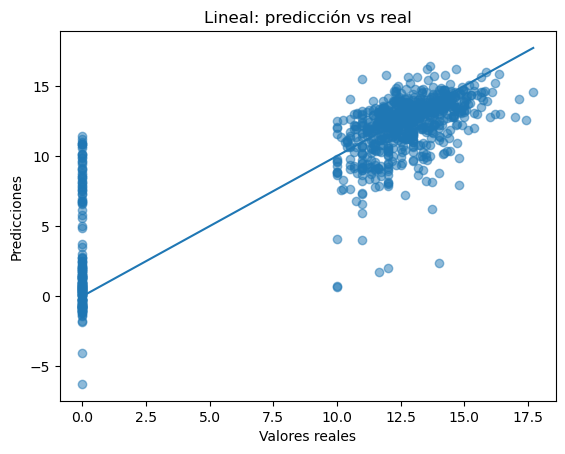

In [48]:
#prediccion real vs real
plt.scatter(y_val, y_val_pred_linear, alpha=0.5)
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Lineal: predicción vs real')

plt.plot(
    [y_val.min(), y_val.max()],

    [y_val.min(), y_val.max()]
)

plt.show()

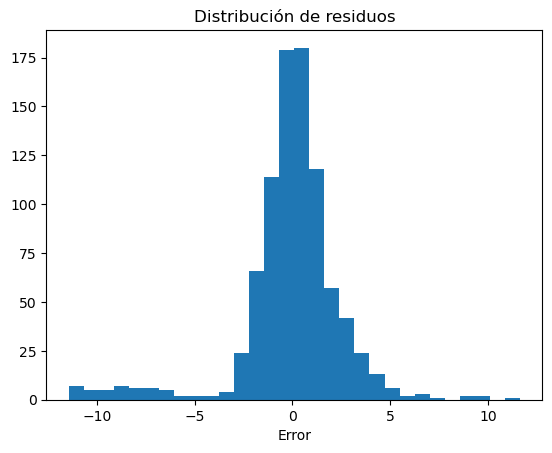

In [49]:
#RESIDUOS
residuos = y_val - y_val_pred_linear

plt.hist(residuos, bins=30)
plt.title('Distribución de residuos')
plt.xlabel('Error')
plt.show()

Como modelo base hemos empleado una regresión lineal, obteniéndose un R² de 0.74 en el conjunto de validación.Este resultado indica que el modelo es capaz de explicar una parte significativa de la variabilidad de la variable objetivo.

El análisis de residuos muestra una distribución aproximadamente centrada en cero, lo que indica que el modelo no presenta un sesgo sistemático. No obstante, se observan colas relativamente largas, lo que refleja la presencia de errores elevados en determinados casos.

La gráfica de predicción frente a valores reales evidencia una buena alineación en torno a la diagonal para la mayoría de observaciones, lo que confirma la capacidad del modelo para capturar la relación entre variables. Sin embargo, se observa una dispersión significativa en los valores cercanos a cero, donde el modelo presenta mayores dificultades.

Este comportamiento sugiere que la variable objetivo presenta una estructura heterogénea, en la que coexisten estudiantes con rendimiento normal y otros con calificaciones nulas, lo que introduce complejidad adicional en el problema de regresión.

Aplicamos validación cruzada a regresión lineal

In [50]:
scores_lineal = cross_val_score(
    modelo_lineal,
    X_train_processed,
    y_train,
    cv=5,
    scoring='r2'
)

print(f'R2 en cada fold: {scores_lineal}')
print(f'R2 medio: {scores_lineal.mean()}')

R2 en cada fold: [0.75788    0.74218896 0.7108952  0.76186613 0.7680752 ]
R2 medio: 0.7481810974059172


Hemos evaluado el modelo de regresión lineal mediante validación cruzada, obteniendo valores de R² comprendidos entre aproximadamente 0.71 y 0.77, con una media cercana a 0.75.

En conjunto, estos resultados confirman que el modelo lineal captura una parte importante de la variabilidad, pero no toda la estructura del problema.

Entrenamos Ridge y Lasso con validación cruzada

In [51]:
#modelos
modelo_ridge = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5
)
modelo_lasso = LassoCV(
    alphas=[0.01, 0.1, 1, 10],
    cv=5,
    max_iter=10000
)

#entrenamos
modelo_ridge.fit(X_train_processed, y_train)
modelo_lasso.fit(X_train_processed, y_train)

#mejores alphas
print(f'Mejor alpha Ridge: {modelo_ridge.alpha_}')
print(f'Mejor alpha Lasso: {modelo_lasso.alpha_}')

Mejor alpha Ridge: 100.0
Mejor alpha Lasso: 0.01


In [52]:
#predecimos
y_val_pred_ridge = modelo_ridge.predict(X_val_processed)
y_val_pred_lasso = modelo_lasso.predict(X_val_processed)

In [53]:
#evaluamos
mae_linear, rmse_linear, r2_linear = evaluar(y_val, y_val_pred_linear, 'REGRESIÓN LINEAL')
mae_ridge, rmse_ridge, r2_ridge = evaluar(y_val, y_val_pred_ridge, 'RIDGE')
mae_lasso, rmse_lasso, r2_lasso = evaluar(y_val, y_val_pred_lasso, 'LASSO')

----REGRESIÓN LINEAL----
MAE: 1.6502
RMSE: 2.6393
R2: 0.7446

----RIDGE----
MAE: 1.5596
RMSE: 2.5999
R2: 0.7521

----LASSO----
MAE: 1.5420
RMSE: 2.5830
R2: 0.7553



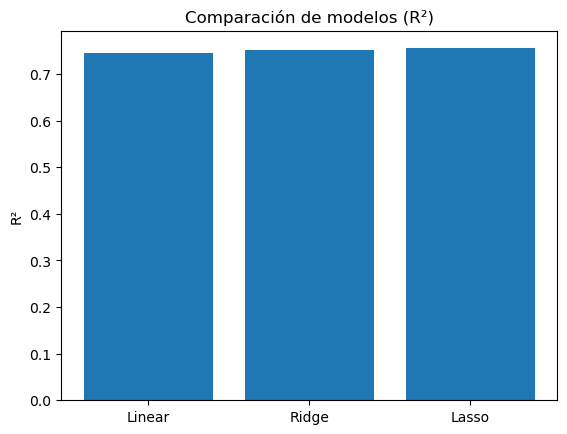

In [54]:
plt.bar(
    ['Linear', 'Ridge', 'Lasso'],
    [r2_linear, r2_ridge, r2_lasso]
)

plt.title('Comparación de modelos (R²)')
plt.ylabel('R²')
plt.show()

Hemos comparado la regresión lineal con sus versiones regularizadas, Ridge y Lasso, con el objetivo de analizar el efecto de la regularización sobre el rendimiento del modelo.

Los resultados muestran que ambos modelos regularizados mejoran el rendimiento respecto al modelo base. En particular, Ridge incrementa ligeramente el R² y reduce el error, lo que indica una mejor capacidad de generalización.

Por su parte, Lasso presenta la mejor performance global, reduciendo tanto el MAE como el RMSE y alcanzando el mayor valor de R², lo que sugiere que además de regularizar, está realizando una selección implícita de variables que mejora el ajuste del modelo.

En conjunto, estas mejoras indican que la regularización sí resulta beneficiosa en este problema, permitiendo obtener modelos más precisos y robustos que la regresión lineal sin penalización.



La similitud en el rendimiento sugiere que el límite del modelo viene determinado por la información disponible en el dataset, más que por la complejidad del modelo.

RANDOM FOREST

In [55]:
"""
Vamos a ajustar los hiperparámetros del modelo de Random Forest
con el objetivo de controlar su complejidad y mejorar su capacidad de generalización. 
En particular, se ha limitado la profundidad de los árboles y se han establecido mínimos en 
el número de muestras por nodo.

Este ajuste permite reducir el riesgo de sobreajuste y obtener un modelo más estable, 
manteniendo la capacidad de capturar relaciones no lineales en los datos.
"""
modelo_rf = RandomForestRegressor(
    n_estimators=200, #más árboles implica más estabilidad
    max_depth = 10, #limitamos profundidad para evitar overfitting
    min_samples_leaf=2, #mínimo en hojas
    min_samples_split=5, #mínimo para dividir nodo
    random_state=42,
    n_jobs=-1 #usa todos los cores
)

#entrenamos
modelo_rf.fit(X_train_processed, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [56]:
#predecimos
y_val_pred_rf = modelo_rf.predict(X_val_processed)

#métricas
mae_rf, rmse_rf, r2_rf = evaluar(y_val, y_val_pred_rf, 'RANDOM FOREST')

----RANDOM FOREST----
MAE: 1.2771
RMSE: 2.3737
R2: 0.7934



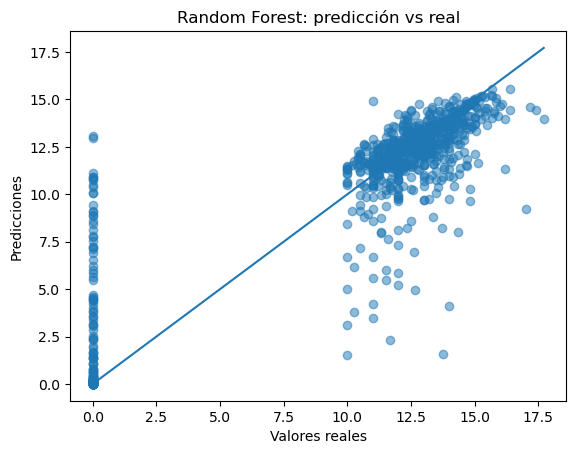

In [57]:
#prediccion real vs real
plt.scatter(y_val, y_val_pred_rf, alpha=0.5)
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Random Forest: predicción vs real')

plt.plot(
    [y_val.min(), y_val.max()],

    [y_val.min(), y_val.max()]
)

plt.show()

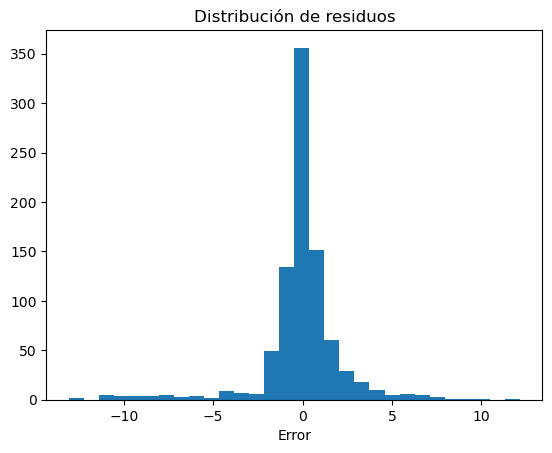

In [58]:
#RESIDUOS
residuos = y_val - y_val_pred_rf

plt.hist(residuos, bins=30)
plt.title('Distribución de residuos')
plt.xlabel('Error')
plt.show()

He aplicado un modelo de Random Forest con el objetivo de capturar posibles relaciones no lineales entre las variables.

Los resultados muestran una mejora clara respecto a los modelos lineales, alcanzando un R² de 0.787 en validación y reduciendo tanto el error absoluto como el error cuadrático medio.

La gráfica de predicción frente a valores reales muestra una mayor concentración de los puntos en torno a la diagonal, lo que indica un mejor ajuste del modelo. Asimismo, la distribución de residuos presenta una menor dispersión, reflejando una reducción en la magnitud de los errores.

Estos resultados sugieren que existen relaciones no lineales en los datos que no son capturadas por los modelos lineales, y que el uso de modelos basados en árboles permite modelar de forma más precisa el rendimiento académico.

No obstante, el modelo sigue mostrando dificultades en la predicción de valores cercanos a cero, lo que refuerza la idea de que la variable objetivo presenta una estructura heterogénea.

Aplicamos validación cruzada a Random Forest

In [59]:
scores_rf = cross_val_score(
    modelo_rf,
    X_train_processed,
    y_train,
    cv=5,
    scoring='r2'
)

print(f'R2 en cada fold: {scores_rf}')
print(f'R2 medio: {scores_rf.mean()}')

R2 en cada fold: [0.79397495 0.76043037 0.74062259 0.78864713 0.83369655]
R2 medio: 0.7834743166156765


Hemos evaluado la estabilidad del modelo mediante validación cruzada utilizando K-Fold con 5 particiones. Los resultados obtenidos muestran valores de R² comprendidos entre aproximadamente 0.74 y 0.83, con una media cercana a 0.78.

Esta baja variabilidad entre particiones indica que el modelo presenta un comportamiento estable y que su rendimiento no depende significativamente de la partición específica de los datos.

Además, el valor medio obtenido es coherente con el rendimiento observado en el conjunto de validación, lo que refuerza la fiabilidad del modelo.

BOOSTING

In [60]:
modelo_gb = GradientBoostingRegressor(
    n_estimators=100, #número de árboles
    learning_rate=0.1, #cuanto aprende cada árbol
    max_depth=3, #profundidad de cada árbol
    random_state=42
)

#entrenamos
modelo_gb.fit(X_train_processed, y_train)

GradientBoostingRegressor(random_state=42)

In [61]:
#predecimos 
y_val_pred_gb = modelo_gb.predict(X_val_processed)

#métricas
mae_gb, rmse_gb, r2_gb = evaluar(y_val, y_val_pred_gb, 'GRADIENT BOOSTING')

----GRADIENT BOOSTING----
MAE: 1.3314
RMSE: 2.3667
R2: 0.7946



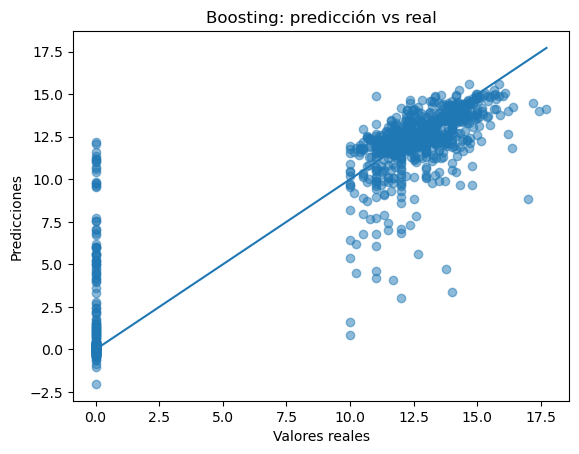

In [62]:
#prediccion real vs real
plt.scatter(y_val, y_val_pred_gb, alpha=0.5)
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Boosting: predicción vs real')

plt.plot(
    [y_val.min(), y_val.max()],

    [y_val.min(), y_val.max()]
)

plt.show()

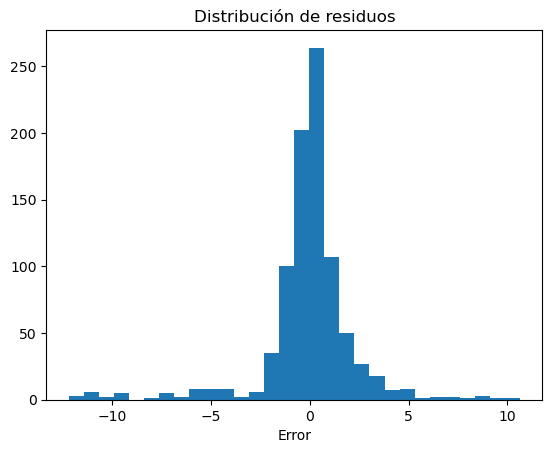

In [63]:
#RESIDUOS
residuos = y_val - y_val_pred_gb

plt.hist(residuos, bins=30)
plt.title('Distribución de residuos')
plt.xlabel('Error')
plt.show()

Hemos aplicado un modelo de Gradient Boosting, obteniendo un R² de 0.7946 en el conjunto de validación, lo que supone una mejora respecto a modelos anteriores.

La gráfica de predicción frente a valores reales muestra una mayor concentración de los puntos en torno a la diagonal, lo que indica un mejor ajuste del modelo. Por su parte, la distribución de residuos aparece centrada en cero y con menor dispersión, reflejando una reducción en la magnitud de los errores.


Aplicamos validación cruzada a boosting

In [64]:
scores_gb = cross_val_score(
    modelo_gb,
    X_train_processed,
    y_train,
    cv=5,
    scoring='r2'
)

print(f'R2 en cada fold: {scores_gb}')
print(f'R2 medio: {scores_gb.mean()}')

R2 en cada fold: [0.77960363 0.78812795 0.72877073 0.7787076  0.82144534]
R2 medio: 0.7793310494279332


Hemos evaluado el modelo de Gradient Boosting mediante validación cruzada, obteniendo valores de R² comprendidos entre aproximadamente 0.73 y 0.82, con una media cercana a 0.78.

Esta variabilidad moderada indica que el modelo presenta un comportamiento estable entre distintas particiones de los datos. Además, el valor medio es coherente con el obtenido en el conjunto de validación, lo que refuerza la fiabilidad del modelo y confirma su capacidad de generalización.

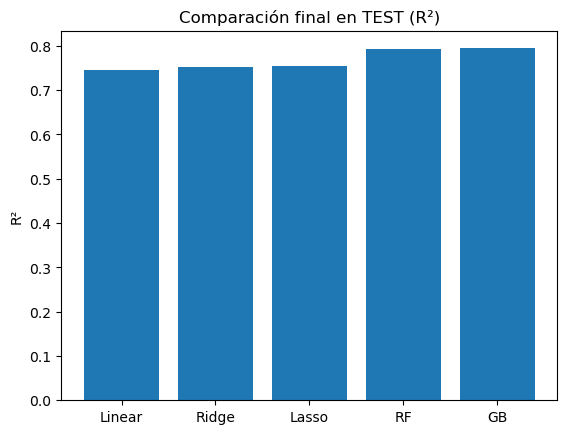

In [65]:
plt.bar(
    ['Linear', 'Ridge', 'Lasso', 'RF', 'GB'],
    [r2_linear, r2_ridge, r2_lasso, r2_rf, r2_gb]
)
plt.title('Comparación final en TEST (R²)')
plt.ylabel('R²')
plt.show()

Hemos comparado distintos modelos de regresión, incluyendo modelos lineales y modelos no lineales basados en árboles.

Los resultados muestran que los modelos lineales ya ofrecen un rendimiento razonable, con valores de R² en torno a 0.74, lo que indica que una parte importante de la variabilidad puede explicarse mediante relaciones aproximadamente lineales.

No obstante, los modelos no lineales, especialmente Random Forest y Gradient Boosting, logran mejorar el rendimiento, alcanzando valores de R² cercanos a 0.79. Esto sugiere la existencia de relaciones no lineales entre las variables que no son capturadas por los modelos lineales.

En particular, Gradient Boosting presenta el mejor rendimiento global, lo que lo convierte en el modelo más adecuado para este problema.

Sin embargo, el análisis gráfico revela que todos los modelos presentan dificultades en la predicción de valores cercanos a cero, lo que indica que la variable objetivo presenta una estructura heterogénea.

En conjunto, estos resultados sugieren que el límite del rendimiento está condicionado en gran medida por la propia naturaleza de los datos, más que por la complejidad del modelo utilizado.

Por tanto, elegimos el modelo de boosting

In [66]:
#predicciones, usamos el modelo que ya hemos entrenado
y_test_pred_gb = modelo_gb.predict(X_test_processed)


#evaluamos
mae_gb_test, rmse_gb_test, r2_gb_test = evaluar(y_test, y_test_pred_gb, 'MODELO GB TEST')

----MODELO GB TEST----
MAE: 1.4427
RMSE: 2.5483
R2: 0.7602



El modelo de Gradient Boosting obtiene un R² de 0.76 en el conjunto de test, mostrando una ligera disminución respecto al conjunto de validación. Esta diferencia es esperable y confirma que el modelo presenta una buena capacidad de generalización, sin evidencias de sobreajuste significativo.